# Replication: Petrosky-Nadeau and Zhang (2017)

**Simon Mishricky**

This notebook replicates **Panel D of Table 1** from:

> Petrosky-Nadeau, N. and Zhang, L. (2017). "Solving the Diamond–Mortensen–Pissarides
> model accurately." *Quantitative Economics*, 8(2), 611–650.

Petrosky-Nadeau and Zhang (PNZ) solve the DMP search-and-matching model
with the Hagedorn and Manovskii (2008) calibration — a parameterisation
that is notoriously difficult to solve numerically because the flow value of
unemployment $b$ is set close to average productivity, making the surplus
from a match very small and the policy function highly non-linear.

PNZ show that standard solution methods (log-linearisation, discrete-state
methods) can produce qualitatively misleading results for this calibration,
and that accurate global methods are essential. Panel D of their Table 1
reports business-cycle statistics — standard deviations, autocorrelations,
and cross-correlations of unemployment, vacancies, and market tightness —
computed from a long simulation of the accurately solved model.

Below, we replicate these statistics using `sparsepea`.

## Model specification

### Environment

The economy consists of a continuum of risk-neutral firms and workers. Each
period, firms decide how many vacancies to post. Unemployed workers search
for jobs, and a CES matching function $m(U, V) = UV / (U^\iota + V^\iota)^{1/\iota}$
governs the rate at which vacancies and job-seekers meet. Matches separate
exogenously at rate $s$ each period. Wages are determined by Nash bargaining
with workers' bargaining weight $\eta$.

### Optimality and complementarity

The firm's free-entry condition equates the expected cost of filling a
vacancy to the expected present value of a filled job:

$$\frac{\kappa_t}{q(\theta_t)} - \lambda_t
= \beta\, \mathbb{E}\!\left[
  X_{t+1} - W_{t+1}
  + (1-s)\!\left(\frac{\kappa_{t+1}}{q(\theta_{t+1})} - \lambda_{t+1}\right)
\right]$$

where $\theta_t \equiv V_t / (1-N_t)$ is labour-market tightness and
$q(\theta_t) = (1 + \theta_t^\iota)^{-1/\iota}$ is the vacancy-filling rate.
Nash-bargained wages are

$$W_t = \eta\bigl(X_t + \kappa_t\theta_t\bigr) + (1-\eta)\, b$$

and the state-dependent vacancy cost is
$\kappa_t = \kappa_K X_t + \kappa_W X_t^\xi$.

Aggregate productivity follows a log-AR(1) process:

$$\ln X_{t+1} = \rho \ln X_t + \sigma\varepsilon_{t+1}, \qquad \varepsilon_{t+1} \sim N(0,1)$$

The complementarity (KKT) conditions reflect the fact that firms cannot
post negative vacancies:

$$\lambda_t \geq 0, \qquad q(\theta_t)\, V_t \geq 0, \qquad
\lambda_t\, q(\theta_t)\, V_t = 0$$

When productivity is sufficiently low, no vacancies are posted
($\theta_t = 0$, $\lambda_t > 0$), and employment declines purely through
exogenous separations. This zero-vacancy region is crucial for generating
the large unemployment fluctuations observed in the data — and is precisely
the feature that log-linear methods fail to capture.

In [1]:
# Packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from sparsepea.models import dmp_jit
from sparsepea.tools import tools

## Solve the model

We solve the model using the same PEA + sparse grid approach demonstrated
in `tutorial.ipynb`. The Hagedorn–Manovskii calibration requires more
iterations to converge (typically 200–400) than the standard RBC model,
reflecting the near-zero surplus that makes the fixed-point mapping
more sensitive to the initial guess.

In [2]:
def initial_guess_dmp(grid_states, γ):
    '''This function provides the initial guess for the PEA algorithm
       in the Diamond Mortensen Pissarides model given a grid of the
       state space'''
    
    grid_size = grid_states[:, 1].size
    
    # Storage space
    guess = np.zeros([grid_size, 1])
    
    for i in range(grid_size):
        
        state = grid_states[i, :]
        x, y = state[0], state[1]
        
        guess[i, :] = γ[0] + γ[1] * x + γ[2] * y
        
    return guess

In [3]:
# Parameters required for the initial guess needed for the PEA algorithm
γ_dmp = np.array([-20, 23.18875328038525, 0.0])

# Initial values required for the simulations
n_initial = 0.0
x_initial = 0.947273

In [4]:
# Initialise an instance of the dmp model
dmp_model = dmp_jit()

# Initialise tools class given the dmp model
tool_box = tools(model=dmp_model, max_iter=1000)
grid_dmp, grid_states_dmp = tool_box.make_states_grid()

# Make a sparse grid require to generate an initial guess
e_dmp = initial_guess_dmp(grid_states_dmp, γ_dmp)

# Solve for the optimal Euler equation and tightness function
e_p, θ_grid, λ_grid, count_dmp = tool_box.compute_solution(e_dmp)
print(count_dmp)

Convergence successful: 521 Iterations


## Simulate the economy

With the converged policy functions $\theta(N, X)$ and $\lambda(N, X)$ in
hand, we simulate the economy forward for 25,000 periods (weekly frequency)
and discard the first 1,000 as burn-in. At each date $t$:

1. Draw a productivity innovation $\varepsilon_t$ and update
   $X_{t+1} = \exp(\rho \ln X_t + \sigma\varepsilon_t)$.
2. Interpolate the policy functions at the current state $(N_t, X_t)$ to
   obtain market tightness $\theta_t$ and the KKT multiplier $\lambda_t$.
3. Compute vacancies $V_t = \theta_t (1-N_t)$, the vacancy-filling rate
   $q(\theta_t)$, the Nash wage $W_t$, and next-period employment
   $N_{t+1} = (1-s)N_t + q(\theta_t)V_t$.

The simulation starts from zero employment ($N_0 = 0$) and a productivity
level slightly below steady state ($X_0 = 0.947$). The burn-in is long
enough for the economy to reach its ergodic distribution regardless of
initial conditions.

In [5]:
def simulation(θ_grid, λ_grid, n_initial, x_initial, ts_length=25000, burn=1000):
    '''This function provides simulations for all of the key variables
       in the Diamond Mortensen Pissarides Model'''
    
    # Extract primitive parameters from dmp model
    ρ = dmp_model.ρ
    σ = dmp_model.σ
    s = dmp_model.s
    κ_k = dmp_model.κ_k
    κ_w = dmp_model.κ_w
    η = dmp_model.η
    b = dmp_model.b
    ξ = dmp_model.ξ
    ι = dmp_model.ι
    
    # Storage space
    x = np.ones(ts_length)
    n = np.ones(ts_length)
    w = np.ones(ts_length-1)
    θ = np.ones(ts_length-1)
    y = np.ones(ts_length-1)
    v = np.ones(ts_length-1)
    u = np.ones(ts_length-1)
    λ = np.ones(ts_length-1)
    
    # Initial values
    n[0] = n_initial
    x[0] = x_initial
    ϵ = np.random.randn(ts_length - 1)
    
    # x bounds
    x_min = np.exp((-3.4645 * σ) / np.sqrt(1.0 - ρ**2.0))
    x_max = np.exp((3.4645 * σ) / np.sqrt(1.0 - ρ**2.0))
    
    for t in range(ts_length - 1):
        
        # Evaluate next period shock and check if it fits within the bounds
        x_val = np.exp(ρ * np.log(x[t]) + σ * ϵ[t])
        x_check = np.minimum(x_val, x_max)
        x[t + 1] = np.maximum(x_check, x_min)
        
        # Create and object ready for interpolation using Tasmanian
        state = np.array([[n[t], x[t]]])
        
        # Interpolate to find θ from the policy function given the current state
        θ_val = tool_box.sparse_interpolate(state, θ_grid)[0][0]
        θ[t] = np.maximum(θ_val, 0.0)
        
        # Interpolate to find λ from the policy function given the current state
        λ_val = tool_box.sparse_interpolate(state, λ_grid)[0][0]
        λ[t] = np.maximum(λ_val, 0.0)
        
        # This function calculates the vacancy filling rate
        q = lambda θ: 1 / ((1 + θ**ι)**(1 / ι))
        
        v[t] = θ[t] * (1 - n[t])                     # Vacancies
        
        u[t] = 1 - n[t]                              # Unemployment
        
        κ = κ_k * x[t] + κ_w * x[t]**(ξ)
        
        w[t] = η * (x[t] + κ) + (1 - η) * b          # Wage
        
        n[t + 1] = (1 - s) * n[t] + q(θ[t]) * v[t]   # Next period employment
        
        y[t] = x[t] * n[t]                           # Output
        
    return n[burn:ts_length-1], θ[burn:ts_length-1], w[burn:ts_length-1], y[burn:ts_length-1], v[burn:ts_length-1], u[burn:ts_length-1], λ[burn:ts_length-1], x[burn:ts_length-1]

In [6]:
# Run the simulations
n, θ, w, y, v, u, λ, x = simulation(θ_grid, λ_grid, n_initial, x_initial)

### Time-series plots

The panels below show the simulated time series for all key variables.
Several features of the Hagedorn–Manovskii calibration are visible:

- **Unemployment** is highly volatile and persistent, with occasional
  spikes corresponding to episodes where the zero-vacancy constraint binds.
- **Vacancies** and **tightness** co-move strongly with productivity,
  reflecting the near-zero surplus: small changes in $X$ produce large
  swings in the incentive to post vacancies.
- **Wages** are comparatively smooth, because the high $b$ compresses the
  Nash-bargained wage into a narrow band around average productivity.

In [7]:
def plot_simulations(variables, labels):
    '''This function plots the simulations calculated from the 
        simulation function'''
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#333333', '#e377c2', '#7f7f7f']
    location = np.array([1, 4, 1, 1, 1, 1, 1, 4])
    
    fig, ax = plt.subplots(4, 2, figsize=(9, 7), dpi=100, sharex=True)
    ax = ax.flatten()
    
    for i in range(labels.size):
        ax[i].plot(variables[i], lw=0.5, color=colors[i], alpha=0.85)
        ax[i].grid(True, alpha=0.15, linestyle='--')
        ax[i].set_ylabel(labels[i], fontsize=8)
        ax[i].tick_params(axis='both', labelsize=7)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        
    plt.tight_layout(h_pad=0.8)
    plt.show()

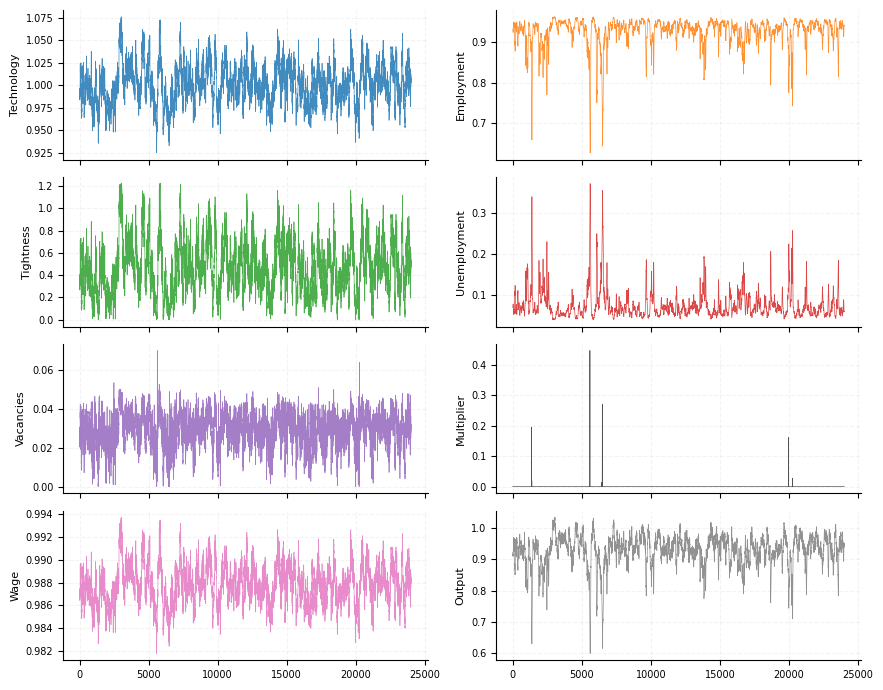

In [8]:
labels = np.array(["Technology",
                   "Employment",
                   "Tightness",
                   "Unemployment",
                   "Vacancies", 
                   "Multiplier",
                   "Wage",
                   "Output"])

variables = np.asarray([x, n, θ, u, v, λ, w, y])

# Plot the simulations
plot_simulations(variables, labels)

## Business-cycle statistics

To compare against the PNZ benchmark, we follow the standard procedure in
the quantitative macro literature:

1. **Aggregate to quarterly frequency** by taking the mean of each weekly
   variable within each quarter.
2. **Normalise** each series by dividing by its sample mean, so that
   standard deviations are interpretable as percentage deviations.
3. **HP-filter** with smoothing parameter $\lambda = 1600$ (the standard
   choice for quarterly data) to extract the cyclical component.
4. **Compute moments** — standard deviations, first-order autocorrelations,
   and cross-correlations — from the filtered series.

The target moments from PNZ Table 1, Panel D are reproduced at the bottom
of this notebook for comparison.

In [9]:
def summary_stats(variables, labels):
    '''This function computes HP-filtered business cycle statistics
       from the simulation output, matching the format of PNZ Table 1'''
    
    # Construct a data frame using stored simulation values
    data_frame = np.column_stack((x, n, θ, u, v, λ, w, y))
    df = pd.DataFrame(data_frame, columns=labels)

    # Create a de-meaned data frame to HP filter the data
    Y = df.tail(12000).copy()
    date = pd.date_range(start='1900-01-01', end=None, periods=len(Y), freq='W')
    Y["week starting"] = date
    
    # Resample to quarterly frequency
    # Use 'QE' for pandas >= 2.2, fall back to 'Q' for older versions
    try:
        Q = Y.resample('QE', on='week starting').mean()
    except ValueError:
        Q = Y.resample('Q', on='week starting').mean()
    Q = Q.divide(Q.mean())
    
    # HP filter the data
    Y_cycle = {}
    Y_trend = {}

    for key, series in Q.items():
        Y_cycle[key], Y_trend[key] = sm.tsa.filters.hpfilter(series, 1600)

    Y_cycle = pd.DataFrame.from_dict(Y_cycle)
    Y_trend = pd.DataFrame.from_dict(Y_trend)
    
    # Calculate the standard deviation and autocorrelation of the variables
    st_dev = {}
    acf = {}
    for key, series in Y_cycle.items():
        st_dev[key] = series.std()
        acf[key] = series.autocorr(lag=1)
    
    # Construct data frames from the calculated standard deviation and autocorrelation values
    st_dev = pd.DataFrame.from_dict(st_dev, orient='index', columns=["Standard deviation"])
    acf = pd.DataFrame.from_dict(acf, orient='index', columns=["Autocorrelation"])    
    
    # Reshape the data frame to only include the variables of consideration
    st_dev = st_dev.iloc[[3, 4, 2, 0]]
    acf = acf.iloc[[3, 4, 2, 0]]
    df_proj = pd.concat([st_dev, acf], axis=1)
    df_y = Y_cycle[['Unemployment', 'Vacancies', 'Tightness', 'Technology']].corr()
    data = pd.concat([df_proj.T, df_y]).round(3)
    table = data.drop(index='Technology')
    
    return table

In [10]:
data = summary_stats(variables, labels)

# Reformat the table to match the Petrovsky-Nadeau and Zhang (2017) Table
# Convert to object dtype first to allow mixed types (floats and strings)
data = data.astype(object)
label = np.array(["Unemployment", "Vacancies", "Tightness"])

for i in range(label.size):
    for j in range(label.size):
        if i >= j:
            data.loc[label[i], label[j]] = ''

data

,Unemployment,Vacancies,Tightness,Technology
Standard deviation,0.253,0.199,0.304,0.013
Autocorrelation,0.794,0.542,0.728,0.728
Unemployment,,-0.531,-0.68,-0.717
Vacancies,,,0.871,0.892
Tightness,,,,0.996


## Target: PNZ Table 1, Panel D

The table below reproduces the benchmark statistics from Petrosky-Nadeau and
Zhang (2017). Our simulated moments (above) should be close to these values
— any remaining differences are due to simulation randomness and minor
differences in the numerical solution method.

|     | Unemployment | Vacancies | Tightness | Technology |
|---:|---:|---:|---:|---:|
| **Std dev** | 0.257 | 0.174 | 0.267 | 0.013 |
| **Autocorr** | 0.823 | 0.586 | 0.759 | 0.760 |

|  | u | v | θ | x |
|---:|---:|---:|---:|---:|
| **u** | 1.000 | −0.567 | −0.662 | −0.699 |
| **v** | | 1.000 | 0.890 | 0.909 |
| **θ** | | | 1.000 | 0.996 |
| **x** | | | | 1.000 |

The key finding of PNZ is that accurate global solution methods —
like the sparse-grid PEA used here — are necessary to capture the large
unemployment fluctuations that arise from the near-zero surplus in the
Hagedorn–Manovskii calibration. Log-linearisation substantially
understates both the volatility of unemployment and the negative
unemployment–vacancy correlation (the Beveridge curve).